In [1]:
# ============================================================
# Sentiment Analysis Visualisation
# Autonomous Vehicle Media Coverage Dissertation
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
# ============================================================
# Load dataset
# ============================================================

DATA_PATH = Path(
    "/Users/yurujia/Desktop/Dissertation Data/final_AV_media_analysis_dataset.xlsx"
)

df = pd.read_excel(DATA_PATH)

print(df.shape)

df.head()

(1809, 12)


,title,source,date_fixed,year,month,analysis_text,topic,sentiment,country,year_month,source_id,sentiment_analysis_text
0,（财经）专访：“中德电动汽车合作远大于竞争”——访蔚来汽车董事长李斌,Xinhua,2017-06-02,2017,2017-06,在李克强总理访问德国期间，蔚来汽车５月３１日在柏林与德国大陆集团签署战略合作协议，主要涉及电...,Business and Commercialisation,1,China,NaN,NaN,NaN
1,（李克强出访配合稿）专访：务实合作始终是中德关系的基本特征——访中国驻德国公使衔参赞王卫东,Xinhua,2017-06-03,2017,2017-06,王卫东说，中德双方应“共塑创新”，构建双边关系发展新引擎。双方在智能制造、人工智能、自动驾驶...,Technology and Innovation,1,China,NaN,NaN,NaN
2,中国新能源汽车全球占比一半,Xinhua,2017-06-06,2017,2017-06,“我们正在逐渐把自动驾驶融入电动汽车这个重大专项、融入未来电动汽车产品当中。”万钢说。,Technology and Innovation,1,China,NaN,NaN,NaN
3,（科技）专家：自动驾驶技术有望让交通事故零伤亡,Xinhua,2017-06-07,2017,2017-06,吉利欧洲研发中心首席执行官方浩瀚日前在位于瑞典哥德堡的总部对新华社记者表示，未来汽车应用自动...,Safety and Risk,1,China,NaN,NaN,NaN
4,（财经）日本预计于２０２３年普及５Ｇ通信,Xinhua,2017-06-07,2017,2017-06,下一代超高速无线通信技术——第五代移动通信技术（５Ｇ）的商业使用区域预计将于２０２３年扩大至...,Technology and Innovation,1,China,NaN,NaN,NaN


In [3]:
# ============================================================
# Inspect variables
# ============================================================

print(df.columns.tolist())

print("\nSources:")
print(df["source"].value_counts())

print("\nSentiment:")
print(df["sentiment"].value_counts())

print("\nCountries:")
print(df["country"].value_counts())

['title', 'source', 'date_fixed', 'year', 'month', 'analysis_text', 'topic', 'sentiment', 'country', 'year_month', 'source_id', 'sentiment_analysis_text']

Sources:
source
Xinhua       1155
WSJ           367
USA Today     287
Name: count, dtype: int64

Sentiment:
sentiment
 1    1236
 0     386
-1     187
Name: count, dtype: int64

Countries:
country
China    1155
USA       654
Name: count, dtype: int64


In [4]:
# ============================================================
# Sentiment labels
# ============================================================

sentiment_map = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}


df["sentiment_label"] = (
    df["sentiment"]
    .map(sentiment_map)
)


df["sentiment_label"].value_counts()

sentiment_label
Positive    1236
Neutral      386
Negative     187
Name: count, dtype: int64

In [5]:
# ============================================================
# Publication style
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

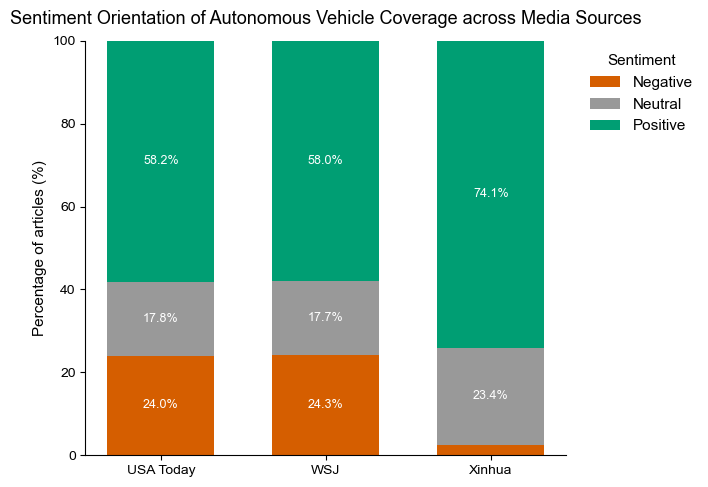

In [15]:
# ============================================================
# Figure 1
# Sentiment distribution by source
# Publication-style version
# ============================================================


# Calculate sentiment distribution
sent_source = (
    df.groupby(["source", "sentiment_label"])
    .size()
    .reset_index(name="count")
)


sent_source["percentage"] = (
    sent_source.groupby("source")["count"]
    .transform(lambda x: x / x.sum() * 100)
)


# Reshape
plot_df = (
    sent_source
    .pivot(
        index="source",
        columns="sentiment_label",
        values="percentage"
    )
    .fillna(0)
)


# Order
plot_df = plot_df[
    ["Negative", "Neutral", "Positive"]
]


# ------------------------------------------------------------
# Colour palette
# ------------------------------------------------------------

sentiment_colors = {
    "Negative": "#D55E00",
    "Neutral": "#999999",
    "Positive": "#009E73"
}


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 5)
)


bottom = np.zeros(len(plot_df))


for sentiment in plot_df.columns:

    values = plot_df[sentiment].values

    ax.bar(
        plot_df.index,
        values,
        bottom=bottom,
        label=sentiment,
        color=sentiment_colors[sentiment],
        width=0.65
    )


    # Add percentage labels
    for i, value in enumerate(values):

        if value >= 3:

            ax.text(
                i,
                bottom[i] + value/2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white"
            )


    bottom += values



# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_ylabel(
    "Percentage of articles (%)"
)

ax.set_xlabel("")


ax.set_ylim(
    0,100
)


ax.set_title(
    "Sentiment Orientation of Autonomous Vehicle Coverage across Media Sources",
    pad=12
)


ax.tick_params(
    axis="x",
    rotation=0
)


# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



ax.legend(
    title="Sentiment",
    frameon=False,
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)


plt.tight_layout()



plt.savefig(
    "Figure1_sentiment_by_source_publication.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

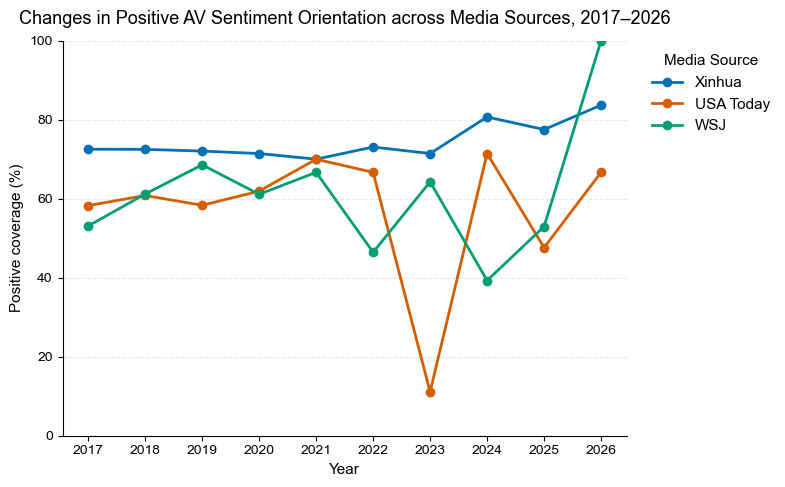

In [22]:
# ============================================================
# Figure 2
# Positive sentiment trend over time
# Publication-style version
# ============================================================


# Calculate yearly sentiment distribution

trend = (
    df.groupby(
        ["year", "source", "sentiment_label"]
    )
    .size()
    .reset_index(name="count")
)


trend["percentage"] = (
    trend.groupby(
        ["year", "source"]
    )["count"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)


# Keep positive sentiment only

positive = trend[
    trend["sentiment_label"] == "Positive"
]


# ------------------------------------------------------------
# Source colour palette
# ------------------------------------------------------------

source_colors = {
    "Xinhua": "#0072B2",       # deep blue
    "USA Today": "#D55E00",    # vermillion
    "WSJ": "#009E73"            # green
}


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8,5)
)

source_order = [
    "Xinhua",
    "USA Today",
    "WSJ"
]


for source in source_order:

    temp = positive[
        positive["source"] == source
    ].sort_values("year")


    ax.plot(
        temp["year"],
        temp["percentage"],
        marker="o",
        markersize=6,
        linewidth=2,
        label=source,
        color=source_colors.get(source)
    )


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_xlabel(
    "Year"
)


ax.set_ylabel(
    "Positive coverage (%)"
)


ax.set_title(
    "Changes in Positive AV Sentiment Orientation across Media Sources, 2017–2026",
    pad=12
)


# Year range

ax.set_xticks(
    sorted(df["year"].unique())
)


ax.set_ylim(
    0,100
)


# Remove unnecessary borders

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Grid

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)


# Legend

ax.legend(
    title="Media Source",
    frameon=False,
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)


plt.tight_layout()


plt.savefig(
    "Figure2_positive_sentiment_trend_publication.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

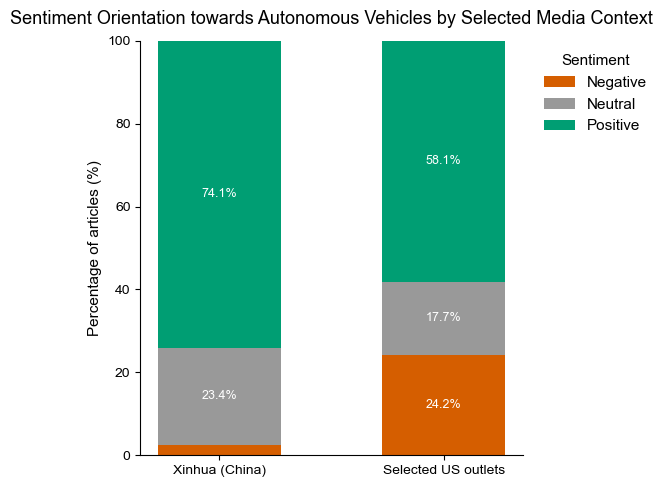

In [27]:
# ============================================================
# Figure 3
# Sentiment orientation by media context
# Publication-style version
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Calculate sentiment distribution
# ------------------------------------------------------------

country_sent = (
    df.groupby(
        ["country", "sentiment_label"]
    )
    .size()
    .reset_index(name="count")
)

country_sent["percentage"] = (
    country_sent.groupby("country")["count"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)


# ------------------------------------------------------------
# Reshape
# ------------------------------------------------------------

country_plot = (
    country_sent
    .pivot(
        index="country",
        columns="sentiment_label",
        values="percentage"
    )
    .fillna(0)
)


# ------------------------------------------------------------
# Sentiment order
# ------------------------------------------------------------

country_plot = country_plot[
    ["Negative", "Neutral", "Positive"]
]


# ------------------------------------------------------------
# Country order
# ------------------------------------------------------------

country_plot = country_plot.loc[
    ["China", "USA"]
]


# ------------------------------------------------------------
# Rename x-axis categories
# ------------------------------------------------------------

country_plot = country_plot.rename(
    index={
        "China": "Xinhua (China)",
        "USA": "Selected US outlets"
    }
)


# ------------------------------------------------------------
# Sentiment colours
# ------------------------------------------------------------

sentiment_colors = {
    "Negative": "#D55E00",
    "Neutral": "#999999",
    "Positive": "#009E73"
}


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6, 5)
)

bottom = np.zeros(len(country_plot))

for sentiment in country_plot.columns:

    values = country_plot[sentiment].values

    ax.bar(
        country_plot.index,
        values,
        bottom=bottom,
        label=sentiment,
        color=sentiment_colors[sentiment],
        width=0.55
    )

    # Add percentage labels
    for i, value in enumerate(values):

        if value >= 4:

            ax.text(
                i,
                bottom[i] + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                color="white"
            )

    bottom += values


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_ylabel(
    "Percentage of articles (%)"
)

ax.set_xlabel("")

ax.set_ylim(
    0, 100
)

ax.set_title(
    "Sentiment Orientation towards Autonomous Vehicles by Selected Media Context",
    pad=12
)

ax.tick_params(
    axis="x",
    rotation=0
)


# ------------------------------------------------------------
# Remove borders
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------

ax.legend(
    title="Sentiment",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)


# ------------------------------------------------------------
# Layout and save
# ------------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "Figure3_sentiment_by_media_context_publication.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# ============================================================
# Sentiment summary table
# ============================================================


summary_table = (
    df.groupby(
        ["source","sentiment_label"]
    )
    .size()
    .reset_index(name="articles")
)


summary_table

,source,sentiment_label,articles
0,USA Today,Negative,69
1,USA Today,Neutral,51
2,USA Today,Positive,167
3,WSJ,Negative,89
4,WSJ,Neutral,65
5,WSJ,Positive,213
6,Xinhua,Negative,29
7,Xinhua,Neutral,270
8,Xinhua,Positive,856


In [10]:
summary_table.to_excel(
    "sentiment_summary_table.xlsx",
    index=False
)